# LAB 3

## Disclosure

> HAIL `Level 3` : In this Laboratory, I use `Gemini` to help me to correct the code.  

本次实验有些尴尬，在马上就要完成实验的时候发现 Gemini 被封了，导致与 AI 的一些对话直接被删光了，还没有保存到 discuss。但是之后一部分还是用 Copilot 完成了，在 discuss.md 中记录了和 Copilot 交流的记录。

- **Update:** 第二天早上登录的时候发现又解封了，在 discuss.md 中的顶部更新了和 `Gemini` 的对话记录。 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Project 1: Ringing Effect

read the image first

Shape: (800, 800)
Data type: float64
MAX value: 255.0
MIN value: 0.0


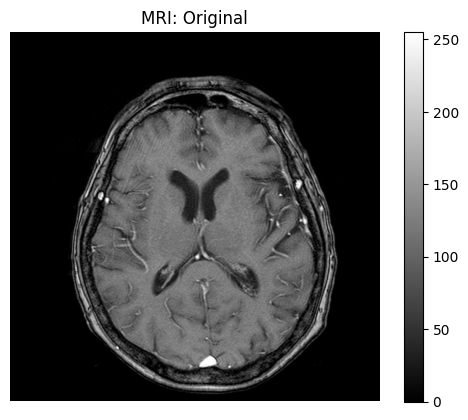

In [2]:
# open the iamge lab3.npy
img = np.load('./input/lab3.npy')

# show the infromation of the image
print("Shape:", img.shape)
print("Data type:", img.dtype)
print("MAX value:", img.max())
print("MIN value:", img.min())

# show the image
plt.imshow(img, cmap='gray')
plt.colorbar()
plt.title("MRI: Original")
plt.axis('off')
plt.show()

### Lospass Filter: Ideal Low-pass, Butterworth(n = 6), Gaussian

In [3]:
# function: apply the filter
def applyFrequencyFilter(img, H):
    F = np.fft.fftshift(np.fft.fft2(img))
    G = H * F
    g = np.fft.ifft2(np.fft.ifftshift(G)).real
    return g

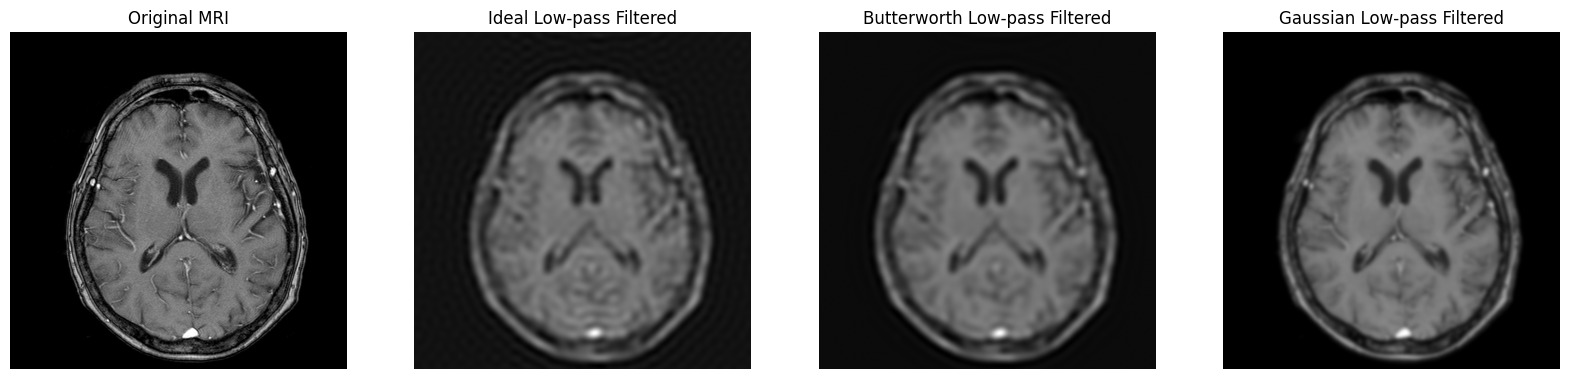

In [4]:
""" Get H: H = 1, when r <= D_0 """
# get the shape of the image
rows, cols = img.shape
# get the axises of the image
u = np.arange(rows) - rows // 2
v = np.arange(cols) - cols // 2
# get the meshgrid of the axises
U, V = np.meshgrid(u, v)
D = np.sqrt(U**2 + V**2)

# set D_0
D_0 = 30

""" Low-pass Filters """
# 1. Ideal Low-pass Filter: H_ideal
H_ideal = (D <= D_0).astype(float)
# 2. Butterworth Low-pass Filter: H_butterworth
n = 6
H_butterworth = 1 / (1 + (D / D_0)**(2 * n))
# 3. Gaussian Low-pass Filter: H_gaussian
H_gaussian = np.exp(-(D**2) / (2 * (D_0**2)))


""" Apply the Filters """
# 1. Ideal Low-pass Filter
g_ideal = applyFrequencyFilter(img, H_ideal)
# 2. Butterworth Low-pass Filter
g_butterworth = applyFrequencyFilter(img, H_butterworth)
# 3. Gaussian Low-pass Filter
g_gaussian = applyFrequencyFilter(img, H_gaussian)


""" Show the Images """
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original MRI')
ax[1].imshow(g_ideal, cmap='gray')
ax[1].set_title('Ideal Low-pass Filtered')
ax[2].imshow(g_butterworth, cmap='gray')
ax[2].set_title('Butterworth Low-pass Filtered')
ax[3].imshow(g_gaussian, cmap='gray')
ax[3].set_title('Gaussian Low-pass Filtered')
for a in ax:
    a.axis('off')
plt.show()

### Point out the ringing effect and explain the cause

理想低通滤波器在图像边缘会产生水波纹状的“振铃效应”，也就是 Ringing Effect。

这是因为：频率域中的非常突兀的阶跃截断在空间域对应的脉冲响应是 Sinc 函数，Sinc 函数具有无限延伸的旁瓣。除了高斯滤波器外，其他滤波器不可避免在空间上存在部分旁瓣能量，因此都有 Ringing Effect。高斯滤波器的傅里叶变换结果还是高斯函数，因此没有旁瓣，在图像上就是变模糊了，但是没有所谓的 Ringing Effect。

可以对一个白点进行滤波，可以清晰观察以上现象。

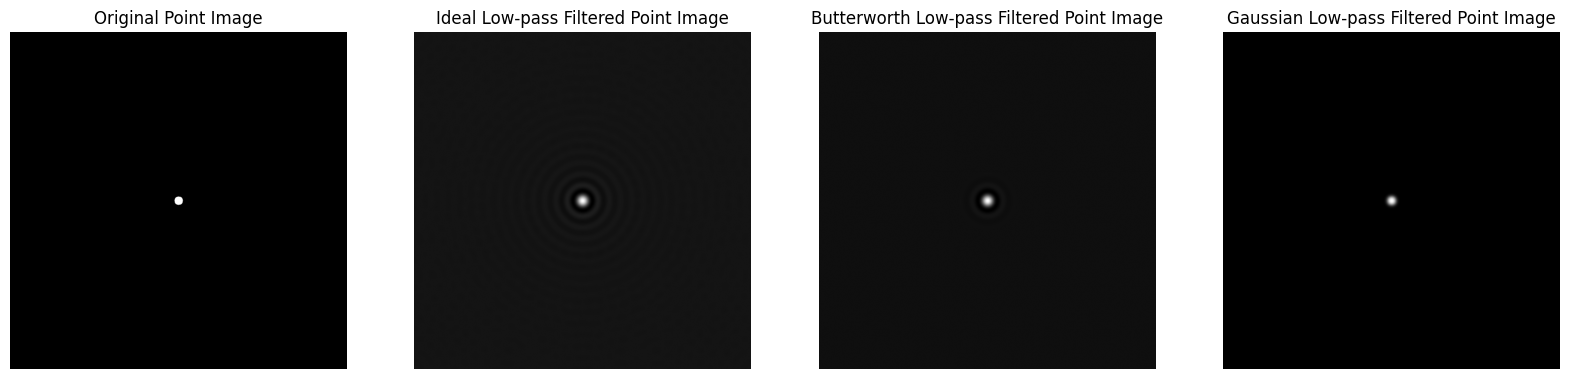

In [5]:
# white point image
point_img = (D <= 10).astype(float)


# Apply the Filters
# 1. Ideal Low-pass Filter
point_g_ideal = applyFrequencyFilter(point_img, H_ideal)
# 2. Butterworth Low-pass Filter
point_g_butterworth = applyFrequencyFilter(point_img, H_butterworth)
# 3. Gaussian Low-pass Filter
point_g_gaussian = applyFrequencyFilter(point_img, H_gaussian)

# Show the Images
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(point_img, cmap='gray')
ax[0].set_title('Original Point Image')
ax[1].imshow(point_g_ideal, cmap='gray')
ax[1].set_title('Ideal Low-pass Filtered Point Image')
ax[2].imshow(point_g_butterworth, cmap='gray')
ax[2].set_title('Butterworth Low-pass Filtered Point Image')
ax[3].imshow(point_g_gaussian, cmap='gray')
ax[3].set_title('Gaussian Low-pass Filtered Point Image')
for a in ax:
    a.axis('off')
plt.show()

## Project 2: Identical Filter

### Implement a spatial filter

In [6]:
# generate Gaussian Kernal
def generateGaussianKernal(sigma):
    # calculate kernel size
    kernel_size = 6 * sigma + 1
    # create the Gaussian kernel
    kernel_axises = np.arange(-kernel_size // 2 + 1, kernel_size // 2 + 1)
    X, Y = np.meshgrid(kernel_axises, kernel_axises)
    kernel_gaussian = np.exp(-(X**2 + Y**2) / (2 * (sigma**2)))
    # normalize the kernel
    return kernel_gaussian / kernel_gaussian.sum()

# calculate 2d convolution
def numpy_conv2d(image, kernel):
    # padding the image
    kernel_height, kernel_width = kernel.shape
    padding_height, padding_width = kernel_height // 2, kernel_width // 2
    padded_img = np.pad(image, ((padding_height, padding_height), (padding_width, padding_width)), mode='edge')

    # calculate the result
    result = np.zeros_like(image, dtype=float)
    for i in range(kernel_height):
        for j in range(kernel_width):
            result += kernel[i, j] * padded_img[i:i+image.shape[0], j:j+image.shape[1]]

    return result

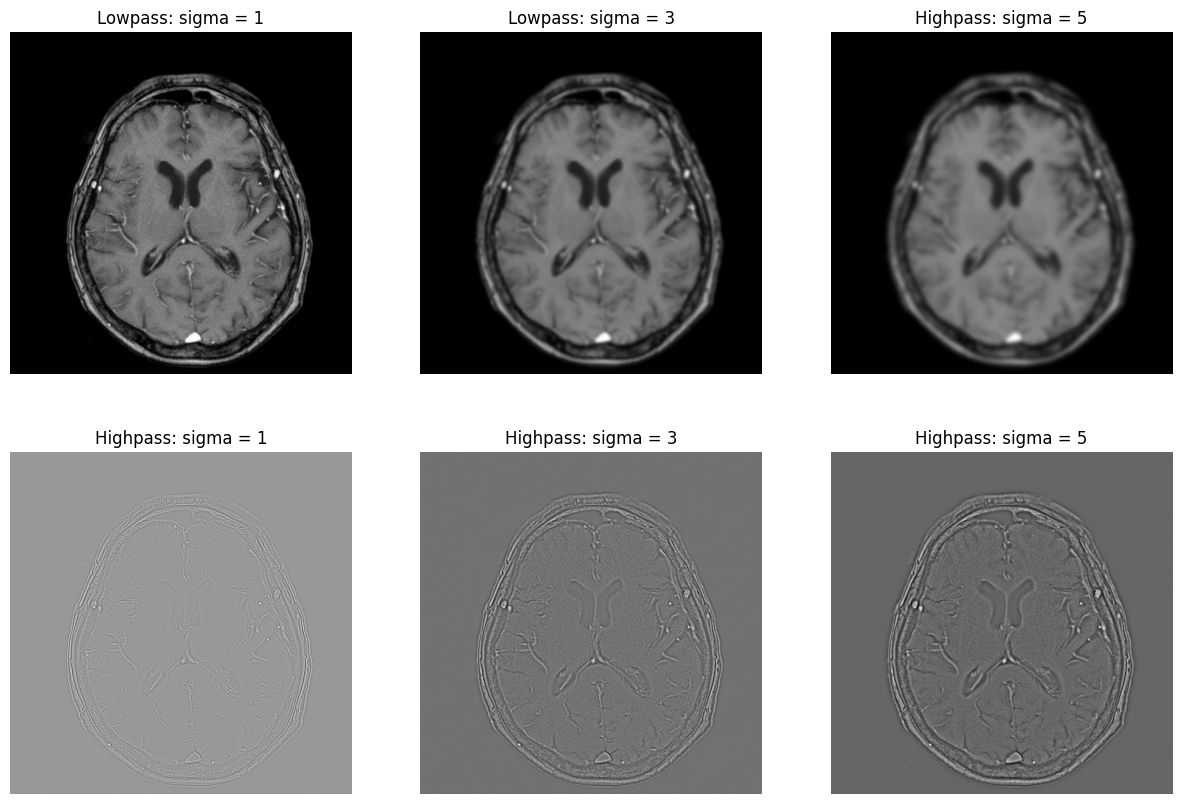

In [7]:
# lowpass filter
kernel_gaussian_1 = generateGaussianKernal(1)
img_spatial_lp_1 = numpy_conv2d(img, kernel_gaussian_1)
img_spatial_hp_1 = img - img_spatial_lp_1
kernel_gaussian_3 = generateGaussianKernal(3)
img_spatial_lp_3 = numpy_conv2d(img, kernel_gaussian_3)
img_spatial_hp_3 = img - img_spatial_lp_3
kernel_gaussian_5 = generateGaussianKernal(5)
img_spatial_lp_5 = numpy_conv2d(img, kernel_gaussian_5)
img_spatial_hp_5 = img - img_spatial_lp_5

# show the images
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax[0, 0].imshow(img_spatial_lp_1, cmap='gray')
ax[0, 0].set_title('Lowpass: sigma = 1')
ax[0, 1].imshow(img_spatial_lp_3, cmap='gray')
ax[0, 1].set_title('Lowpass: sigma = 3')
ax[0, 2].imshow(img_spatial_lp_5, cmap='gray')
ax[0, 2].set_title('Highpass: sigma = 5')
ax[1, 0].imshow(img_spatial_hp_1, cmap='gray')
ax[1, 0].set_title('Highpass: sigma = 1')
ax[1, 1].imshow(img_spatial_hp_3, cmap='gray')
ax[1, 1].set_title('Highpass: sigma = 3')
ax[1, 2].imshow(img_spatial_hp_5, cmap='gray')
ax[1, 2].set_title('Highpass: sigma = 5')
for a in ax.flatten():
    a.axis('off')
plt.show()

### Apply frequency filter

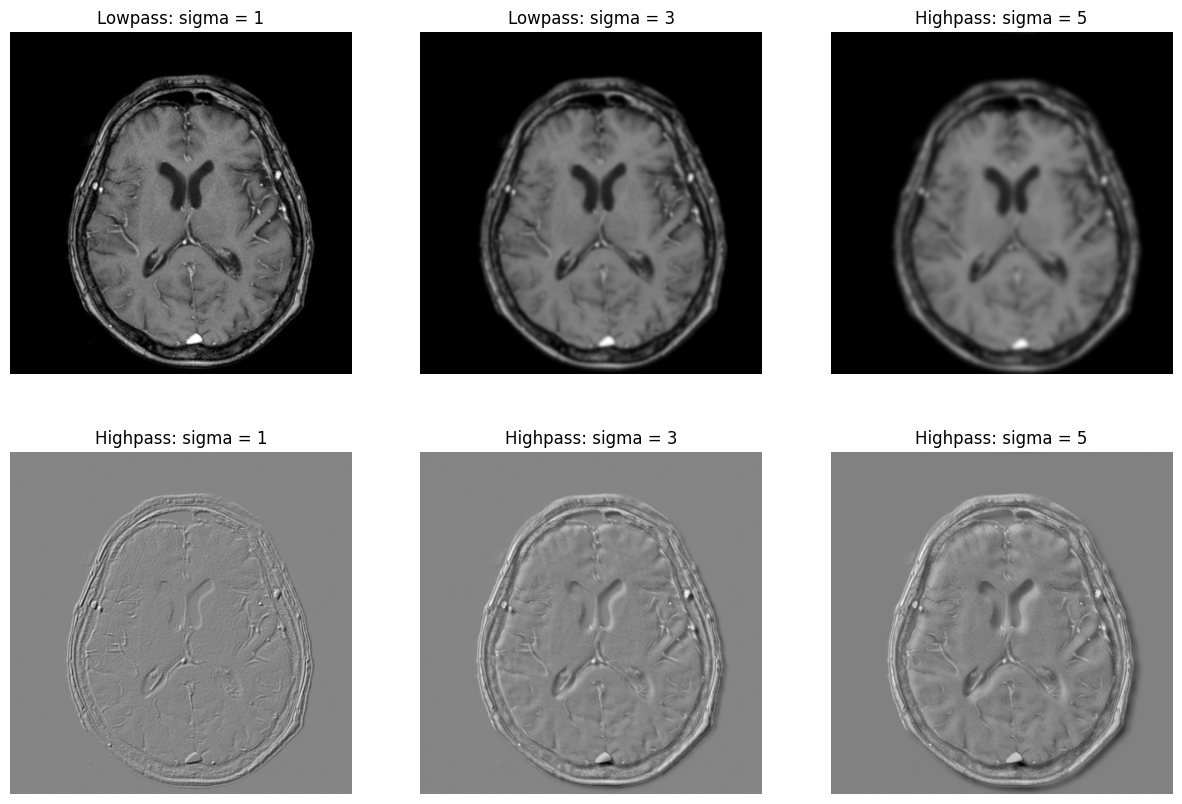

In [8]:
# perform Fourier Transform on image
F_img = np.fft.fftshift(np.fft.fft2(img))
# perform Fourier Transform on kernel
H_kernel_lp_1 = np.fft.fftshift(np.fft.fft2(kernel_gaussian_1, s=img.shape))
H_kernel_hp_1 = np.ones_like(H_kernel_lp_1) - H_kernel_lp_1
H_kernel_lp_3 = np.fft.fftshift(np.fft.fft2(kernel_gaussian_3, s=img.shape))
H_kernel_hp_3 = np.ones_like(H_kernel_lp_3) - H_kernel_lp_3
H_kernel_lp_5 = np.fft.fftshift(np.fft.fft2(kernel_gaussian_5, s=img.shape))
H_kernel_hp_5 = np.ones_like(H_kernel_lp_5) - H_kernel_lp_5

# apply frequency filter
img_frequency_lp_1 = np.fft.ifft2(np.fft.ifftshift(F_img * H_kernel_lp_1)).real
img_frequency_lp_3 = np.fft.ifft2(np.fft.ifftshift(F_img * H_kernel_lp_3)).real
img_frequency_lp_5 = np.fft.ifft2(np.fft.ifftshift(F_img * H_kernel_lp_5)).real
img_frequency_hp_1 = np.fft.ifft2(np.fft.ifftshift(F_img * H_kernel_hp_1)).real
img_frequency_hp_3 = np.fft.ifft2(np.fft.ifftshift(F_img * H_kernel_hp_3)).real
img_frequency_hp_5 = np.fft.ifft2(np.fft.ifftshift(F_img * H_kernel_hp_5)).real

# show the images
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax[0, 0].imshow(img_frequency_lp_1, cmap='gray')
ax[0, 0].set_title('Lowpass: sigma = 1')
ax[0, 1].imshow(img_frequency_lp_3, cmap='gray')
ax[0, 1].set_title('Lowpass: sigma = 3')
ax[0, 2].imshow(img_frequency_lp_5, cmap='gray')
ax[0, 2].set_title('Highpass: sigma = 5')
ax[1, 0].imshow(img_frequency_hp_1, cmap='gray')
ax[1, 0].set_title('Highpass: sigma = 1')
ax[1, 1].imshow(img_frequency_hp_3, cmap='gray')
ax[1, 1].set_title('Highpass: sigma = 3')
ax[1, 2].imshow(img_frequency_hp_5, cmap='gray')
ax[1, 2].set_title('Highpass: sigma = 5')
for a in ax.flatten():
    a.axis('off')
plt.show()

### Implement a Laplacian Highpass Filter

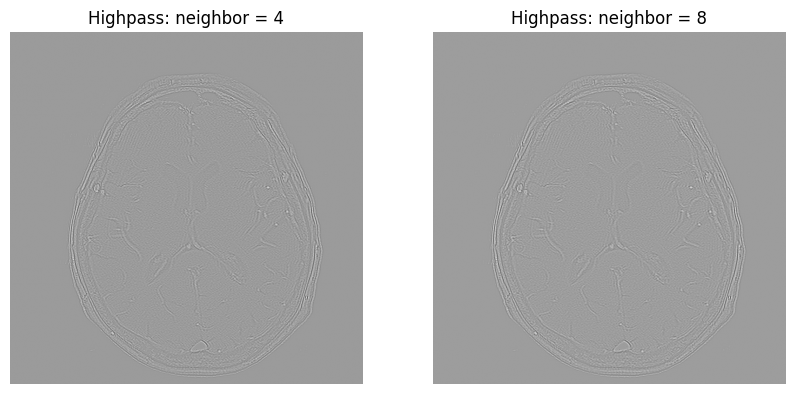

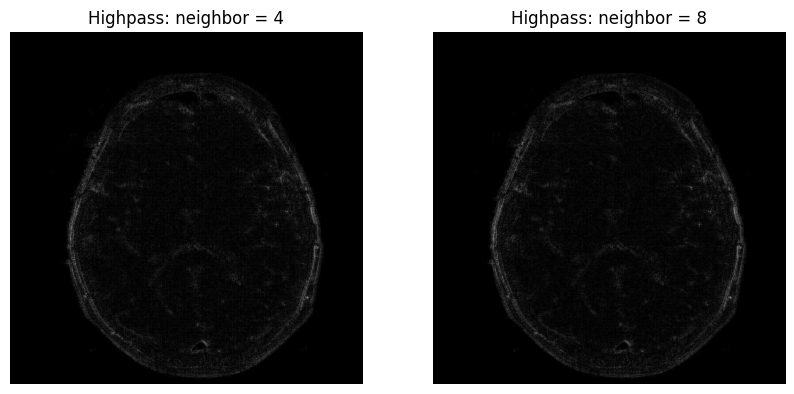

In [9]:
# Laplacian Highpass Filter
# neighbor: 4
laplacian_4 = np.array([[ 0, -1,  0], 
                        [-1,  4, -1], 
                        [ 0, -1,  0]], dtype=float)
# neighbor: 8
laplacian_8 = np.array([[-1, -1, -1], 
                        [-1,  8, -1], 
                        [-1, -1, -1]], dtype=float)

# Perform Highpass Filter on image
img_laplacian_4 = numpy_conv2d(img, laplacian_4)
img_laplacian_8 = numpy_conv2d(img, laplacian_8)

# show the result
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_laplacian_4, cmap='gray')
ax[0].set_title('Highpass: neighbor = 4')
ax[1].imshow(img_laplacian_8, cmap='gray')
ax[1].set_title('Highpass: neighbor = 8')
for a in ax:
    a.axis("off")
plt.show()

# show the result
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(np.abs(img_laplacian_4), cmap='gray')
ax[0].set_title('Highpass: neighbor = 4')
ax[1].imshow(np.abs(img_laplacian_8), cmap='gray')
ax[1].set_title('Highpass: neighbor = 8')
for a in ax:
    a.axis("off")
plt.show()

纵向对比一下:

- 频率域 vs 空间域：空间域卷积理论上等价于频率域乘积。但从结果来看，两者的高通滤波后的图像差异还是挺大的。这一差异可以从数学上推导出来，主要来源于对高斯核的截断。因为要满足 $G = F \cdot H$，必须满足两矩阵的大小相同，那么高斯核的大小就不可能在频率域无限延伸，真正参与计算的滤波器是 $H_{\text{padded}} = H \cdot p_{u \le u_0, v \le v_0}$。在此基础上，就会导致通过高通滤波器的图像在空间域上，呈现一定的边缘平滑。

- 高斯高通 vs 拉普拉斯：拉普拉斯对高频极其敏感，边缘提取锐利但会严重放大噪声。高斯高通等价于先平滑再提取高频，过渡平滑，具有更好的抗噪性。

## Project 3: Notch Filter

read the noise image

Shape: (800, 800)
Data type: float64
MAX value: 255.0
MIN value: 0.0


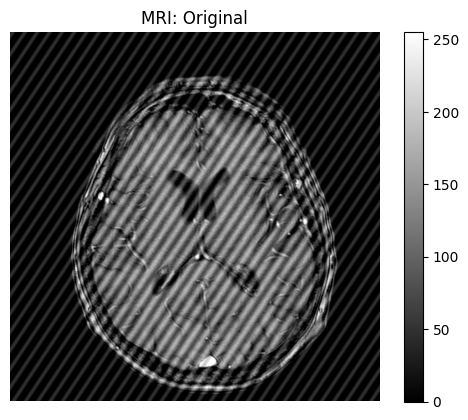

In [10]:
# open the iamge lab3.npy
img_noise = np.load('./input/lab3_noise.npy')

# show the infromation of the image
print("Shape:", img_noise.shape)
print("Data type:", img_noise.dtype)
print("MAX value:", img_noise.max())
print("MIN value:", img_noise.min())

# show the image
plt.imshow(img_noise, cmap='gray')
plt.colorbar()
plt.title("MRI: Original")
plt.axis('off')
plt.show()

看看频域图像

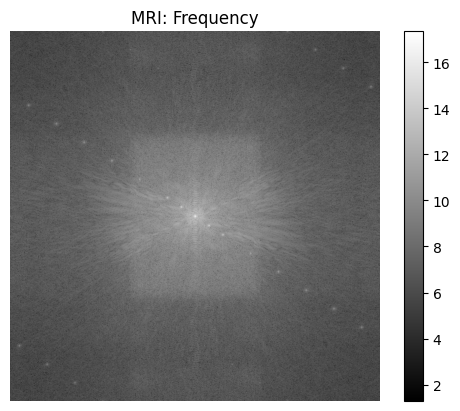

In [11]:
F_img_noise = np.fft.fftshift(np.fft.fft2(img_noise))

# show the image
plt.imshow(np.log(1 + np.abs(F_img_noise)), cmap='gray')
plt.colorbar()
plt.title("MRI: Frequency")
plt.axis('off')
plt.show()

画出所有白点的位置

In [12]:
import cv2

def drawCircle(img: np.ndarray, x: int, y: int, r: int, w: int):
    # color
    color = (1.0, 0, 0) if img.dtype.kind == 'f' else (255, 0, 0)
    # img_rgb
    if img.ndim == 2:
        img_rgb = img_rgb = np.stack([img, img, img], axis=-1)
    else:
        img_rgb = img.copy()
    return cv2.circle(img_rgb, (x, y), r, color, w)

(x, y):  [(40, 160), (100, 200), (160, 240), (220, 280), (280, 320), (340, 360), (400, 400), (460, 440), (520, 480), (580, 520), (640, 560), (700, 600), (760, 640)]
(x, y):  [(660, 40), (720, 80), (780, 120)]
(x, y):  [(20, 680), (80, 720), (140, 760)]
(x, y):  [(40, 160), (100, 200), (160, 240), (220, 280), (280, 320), (340, 360), (460, 440), (520, 480), (580, 520), (640, 560), (700, 600), (760, 640), (660, 40), (720, 80), (780, 120), (20, 680), (80, 720), (140, 760), (370, 380), (430, 420)]


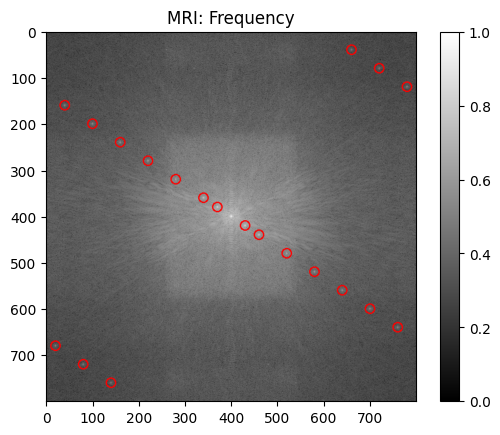

In [13]:
# draw circle
img_show = np.log(1 + np.abs(F_img_noise))
img_show_norm = (img_show - img_show.min()) / (img_show.max() - img_show.min())

# img_circle = drawCircle(img_circle, 660, 40, 10, 2)
# img_circle = drawCircle(img_circle, 20, 680, 10, 2)
xy_list = [(i, (i + 200) // 3 * 2) for i in range(40, 800, 60)]
print("(x, y): ", xy_list)
xy_up_list = [(i, i // 3 * 2 - 400) for i in range(660, 800, 60)]
print("(x, y): ", xy_up_list)
xy_down_list = [(j // 2 * 3 - 1000, j) for j in range(680, 800, 40)]
print("(x, y): ", xy_down_list)
xy_list = xy_list + xy_up_list + xy_down_list
xy_list.append((370, 380))
xy_list.append((430, 420))
xy_list.remove((400, 400))
print("(x, y): ", xy_list)
img_circle = img_show_norm
for i in range(len(xy_list)):
    img_circle = drawCircle(img_circle, int(xy_list[i][0]), int(xy_list[i][1]), 10, 2)


# show the image
plt.imshow(img_circle, cmap='gray')
plt.colorbar()
plt.title("MRI: Frequency")
plt.show()

把所有的坐标放在列表 `xy_list` 中。

现在只需要把所有坐标用高斯陷波器把所有坐标都平滑掉就行。

In [14]:
def generateSoftGaussianNotchFilter(img: np.ndarray, v0: int, u0: int, sigma: float, alpha: float = 1.0):
    height, width = img.shape
    u = np.arange(height)
    v = np.arange(width)
    V, U = np.meshgrid(v, u)

    D_k1_sq = (U - u0) ** 2 + (V - v0) ** 2
    D_k2_sq = (U + u0) ** 2 + (V + v0) ** 2

    notch_1 = np.exp(-D_k1_sq / (2 * sigma ** 2))
    notch_2 = np.exp(-D_k2_sq / (2 * sigma ** 2))

    H = (1.0 - alpha * notch_1) * (1.0 - alpha * notch_2)
    return np.clip(H, 0.0, 1.0)


def applyCombinedSoftNotchFilter(img: np.ndarray, notch_points: list[tuple[int, int]], sigma: float = 5.0, alpha: float = 1.0):
    F = np.fft.fftshift(np.fft.fft2(img))
    H_total = np.ones(img.shape, dtype=np.float64)

    for v0, u0 in notch_points:
        H_total *= generateSoftGaussianNotchFilter(img, v0, u0, sigma=sigma, alpha=alpha)

    G = F * H_total
    g = np.fft.ifft2(np.fft.ifftshift(G)).real
    return g, H_total, F, G

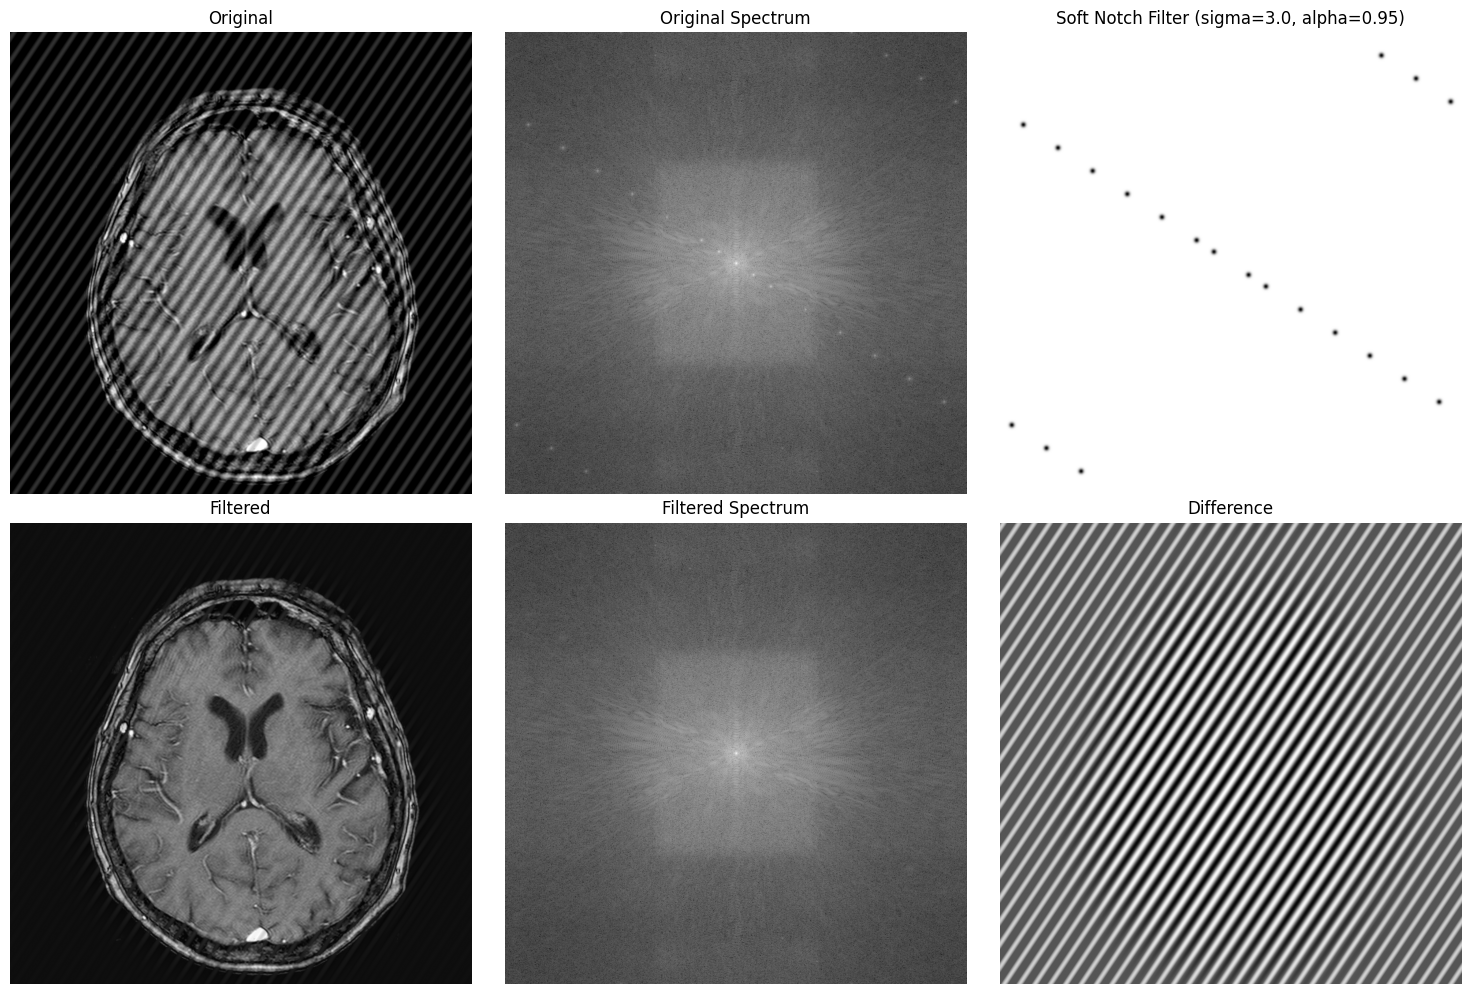

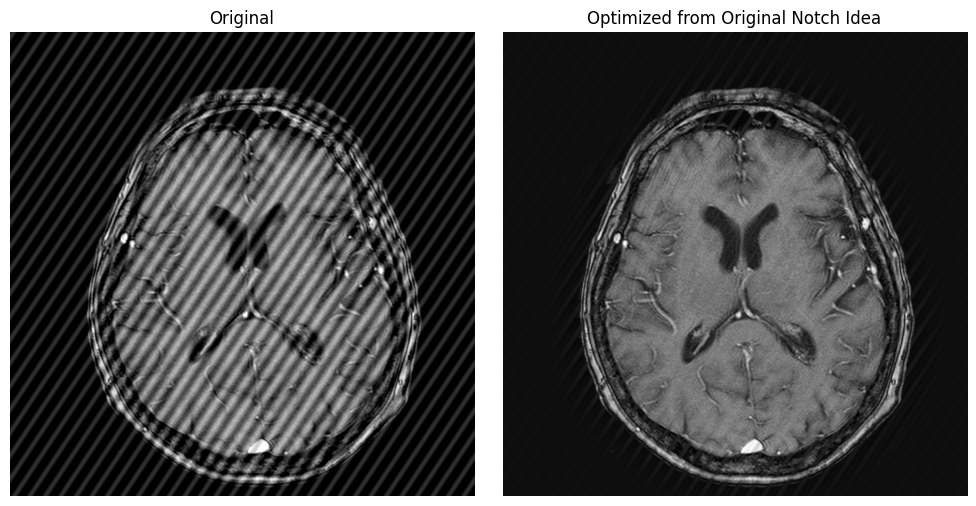

In [15]:
# optimize the original idea: keep the same coordinates, but use a smoother notch and apply it once in frequency domain
sigma_new = 3.0
alpha_new = 0.95

img_repair_soft, H_soft, F_soft_original, F_soft_filtered = applyCombinedSoftNotchFilter(
    img_noise,
    xy_list,
    sigma=sigma_new,
    alpha=alpha_new,
)

fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax[0, 0].imshow(img_noise, cmap='gray')
ax[0, 0].set_title('Original')
ax[0, 1].imshow(np.log(1 + np.abs(F_soft_original)), cmap='gray')
ax[0, 1].set_title('Original Spectrum')
ax[0, 2].imshow(H_soft, cmap='gray')
ax[0, 2].set_title(f'Soft Notch Filter (sigma={sigma_new}, alpha={alpha_new})')

ax[1, 0].imshow(img_repair_soft, cmap='gray')
ax[1, 0].set_title('Filtered')
ax[1, 1].imshow(np.log(1 + np.abs(F_soft_filtered)), cmap='gray')
ax[1, 1].set_title('Filtered Spectrum')
ax[1, 2].imshow(img_noise - img_repair_soft, cmap='gray')
ax[1, 2].set_title('Difference')

for a in ax.ravel():
    a.axis('off')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_noise, cmap='gray')
ax[0].set_title('Original')
ax[1].imshow(img_repair_soft, cmap='gray')
ax[1].set_title('Optimized from Original Notch Idea')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

陷波器实验还是用了比较多时间的，主要是 notch 陷波器的选择比较耗时间。

最开始的时候选用了巴特沃兹陷波器，但是陷波的结果非常不理想，在频域上看上去已经把所有的缺陷都已经补上了，但是空间域上还是有很多条纹。

在多次尝试参数后，发现将 notch 的最小值变成负值反而效果比较好。在询问 Gemini 后得知这是因为复数具有相位便宜的原因。然后在 Gemini 的建议下采用了高斯陷波器，并选用更加平滑的陷波函数。

最后得到的效果也是好了很多。